In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
dataset=pd.read_excel('Trail1  Powder e.xlsx')
X=dataset.drop(dataset.columns[[9,15,17]],axis=1).iloc[ : , :-4].values
y=dataset.iloc[ : ,-4].values

In [ ]:
df = pd.read_excel('Trail1  Powder e.xlsx')
df=df.drop(df.columns[[9,15,17,19,20,21]],axis=1)

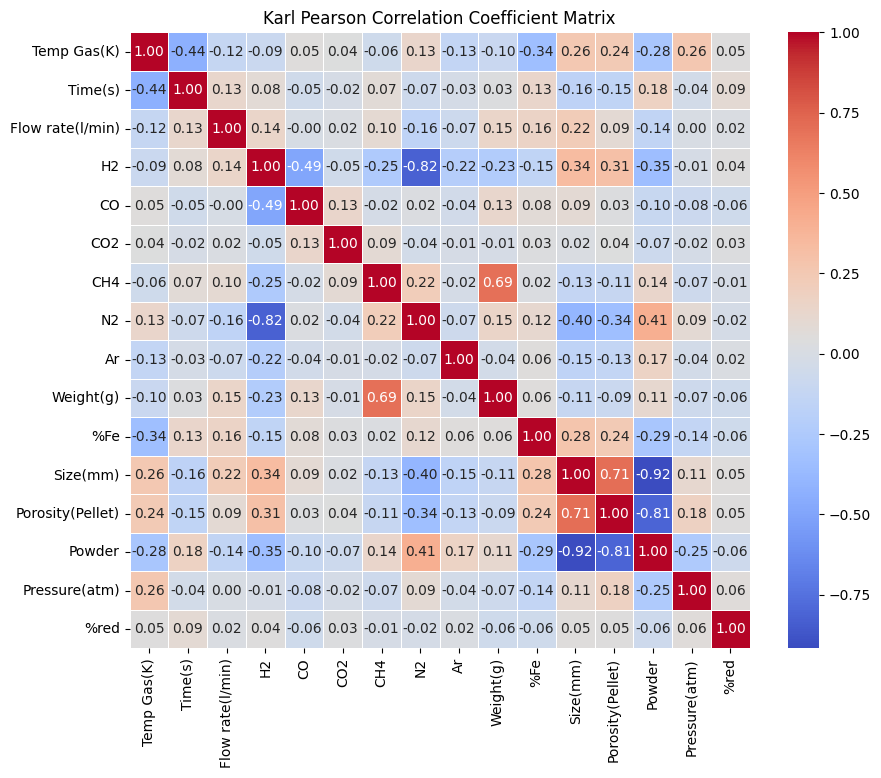

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',linewidths=0.5,fmt=".2f")
plt.title("Karl Pearson Correlation Coefficient Matrix")
plt.show()

In [ ]:
X.shape

(1023, 15)

In [ ]:
powder_count = df[df['Powder'] == 1].shape[0]

pellet_count = df[df['Porosity(Pellet)'] !=0].shape[0]

print(f"Number of Powder data points: {powder_count}")
print(f"Number of Pellet data points: {pellet_count}")

Number of Powder data points: 450
Number of Pellet data points: 573


##Removing Powder feature

In [ ]:
dataset=pd.read_excel('Trail1  Powder e.xlsx')
X=dataset.drop(dataset.columns[[9,14,15,17]],axis=1).iloc[ : , :-4].values
y=dataset.iloc[ : ,-4].values

In [ ]:
X.shape

(1023, 14)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
y_test.shape

(205,)

#Dry run for the best Model

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor=RandomForestRegressor()
regressor.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred=regressor.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.9234430812854686
NRMSE : 8.742164919394947 %


##Linear Regressor

In [ ]:
from sklearn.linear_model import LinearRegression
regres=LinearRegression()
regres.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=regres.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

-0.029377797923568094
NRMSE : 32.05635735531563 %


##Kernel SVM

In [ ]:
from sklearn.svm import SVR
svr=SVR(kernel='rbf')
svr.fit(X_train,y_train)

SVR()

In [ ]:
y_pred=svr.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.07253881223085912
NRMSE : 30.428086666520855 %


##Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree=DecisionTreeRegressor()
tree.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred=tree.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.8407306696889316
NRMSE : 12.6093543453522 %


##KNearest Neighbours

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(X_train,y_train)

KNeighborsRegressor()

In [ ]:
y_pred=knn.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.49631741953867914
NRMSE : 22.423594852340596 %


##LightGBM

In [ ]:
!pip install -q lightgbm

In [ ]:
import lightgbm as lgb
lgbr = lgb.LGBMRegressor()
lgbr.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 374
[LightGBM] [Info] Number of data points in the train set: 818, number of used features: 12
[LightGBM] [Info] Start training from score 61.511418
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMRegressor()

In [ ]:
y_pred=lgbr.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.9244823306029439
NRMSE : 8.682625343974127 %


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


##XGBoost

In [ ]:
from xgboost import XGBRegressor
reg=XGBRegressor()
reg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred=reg.predict(X_test)
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test,y_pred))
print("NRMSE :",root_mean_squared_error(y_test,y_pred)*100/(y_test.max()-y_test.min()),"%")

0.9446278434025047
NRMSE : 7.434854804496853 %


In [ ]:
X_test.shape

(205, 14)

#Analysis on the Best model

##PCA and 3D Visualsation

In [ ]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go
pca=PCA(n_components=3)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)

reg_pca=XGBRegressor()
reg_pca.fit(X_train_pca,y_train)

y_pre=reg_pca.predict(X_test_pca)
rmse=root_mean_squared_error(y_test,y_pre)
r2=r2_score(y_test, y_pre)
print(f"R2 Score: {r2}")
print("NRMSE :",root_mean_squared_error(y_test,y_pre)*100/(y_test.max()-y_test.min()),"%")

R2 Score: 0.7816375591218825
NRMSE : 14.764397953995761 %


In [ ]:
x_surf = np.linspace(X_train_pca[:, 0].min(), X_train_pca[:, 0].max(), 30)
y_surf = np.linspace(X_train_pca[:, 1].min(), X_train_pca[:, 1].max(), 30)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = reg_pca.predict(np.c_[x_surf.ravel(), y_surf.ravel(), np.zeros_like(x_surf.ravel())]).reshape(x_surf.shape)

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    z=X_test_pca[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color=y_test,
        colorscale='Viridis',
        opacity=0.7
    ),
    name='Test Data'
))

x_surf = np.linspace(np.min(X_train_pca[:, 0]), np.max(X_test_pca[:, 0]), 30)
y_surf = np.linspace(np.min(X_train_pca[:, 1]), np.max(X_test_pca[:, 1]), 30)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = reg_pca.predict(np.c_[x_surf.ravel(), y_surf.ravel(), np.zeros_like(x_surf.ravel())]).reshape(x_surf.shape)

fig.add_trace(go.Surface(
    x=x_surf,
    y=y_surf,
    z=z_surf,
    colorscale='Reds',
    opacity=0.6,
    name='XGBoost Regression Surface'
))

fig.update_layout(
    title='3D PCA Plot with XGBoost Regression',
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3'
    ),
    width=800,
    height=600
)
fig.show()

In [ ]:
X_test.shape

(205, 14)

##Hyper Parameter Tuning by Bayesian optimization

In [ ]:
!pip install -q optuna

In [ ]:
import optuna

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'objective': 'reg:squarederror',
        'verbosity': 0,
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)

[I 2025-08-17 07:10:48,567] A new study created in memory with name: no-name-b3ddd5ab-2c12-423c-90b9-cd263a5a4c24
[I 2025-08-17 07:10:48,769] Trial 0 finished with value: 0.9650363707548449 and parameters: {'learning_rate': 0.25029402794418143, 'max_depth': 5, 'reg_lambda': 2.7479791701929734, 'n_estimators': 449}. Best is trial 0 with value: 0.9650363707548449.
[I 2025-08-17 07:10:48,972] Trial 1 finished with value: 0.9627734817538568 and parameters: {'learning_rate': 0.2374498537966379, 'max_depth': 5, 'reg_lambda': 1.4934712901798952, 'n_estimators': 464}. Best is trial 0 with value: 0.9650363707548449.
[I 2025-08-17 07:10:49,067] Trial 2 finished with value: 0.9264238636900293 and parameters: {'learning_rate': 0.08840234300011772, 'max_depth': 3, 'reg_lambda': 1.8341320763076228, 'n_estimators': 245}. Best is trial 0 with value: 0.9650363707548449.
[I 2025-08-17 07:10:49,264] Trial 3 finished with value: 0.955232589790026 and parameters: {'learning_rate': 0.08064060322824954, 'max

Best Params: {'learning_rate': 0.16262372881375775, 'max_depth': 4, 'reg_lambda': 2.9284780121141587, 'n_estimators': 314}


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

best_params_xgb = {
    'learning_rate': 0.29805672908916814,
    'max_depth': 3,
    'reg_lambda': 2.1909055098761008,
    'n_estimators': 929,
    'objective': 'reg:squarederror',
    'verbosity': 0,
    'random_state': 42
}

xgb_model = XGBRegressor(**best_params_xgb)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("NRMSE:", root_mean_squared_error(y_test, y_pred) * 100 / (y_test.max() - y_test.min()), "%")

R2 Score: 0.9723741458230623
NRMSE: 5.251515236870315 %


In [ ]:
print(y_pred)

[ 24.169891   42.056934   97.80847    73.698616   98.38936    82.42914
  88.85581    46.965755   95.19218    78.89149    88.71205    63.666256
  26.394985   90.98314     7.4217963  62.327293  105.80907    99.45589
  75.80941    77.57009    88.82699    93.087585   78.50077    92.08578
  85.273636   77.923615  100.49069     0.9787033  96.09229    55.573395
  47.20341    48.044544   79.90845    91.783936   59.300953   67.05242
  99.29596    93.25311    17.858702   62.592148   83.09048    30.911589
  27.067549  100.63332    95.58277     3.171294   41.413094   86.31942
  52.79216    96.67074   107.98652    91.166016   74.40176    67.90908
  86.215645   85.5384      4.308134   50.6313     38.430264   83.53225
  57.972958   50.586044   96.14709    54.629616   61.644806    9.146667
  93.86235    92.518135   61.506805   39.523273   85.464676   83.6431
  57.098297   94.332565   74.99431    94.91795    28.174738   89.44195
   9.733111  -11.384832   90.772125   53.802753   16.380316   19.159122
  

In [ ]:
X_test.shape

(205, 14)

##Actual vs Predcited Plots

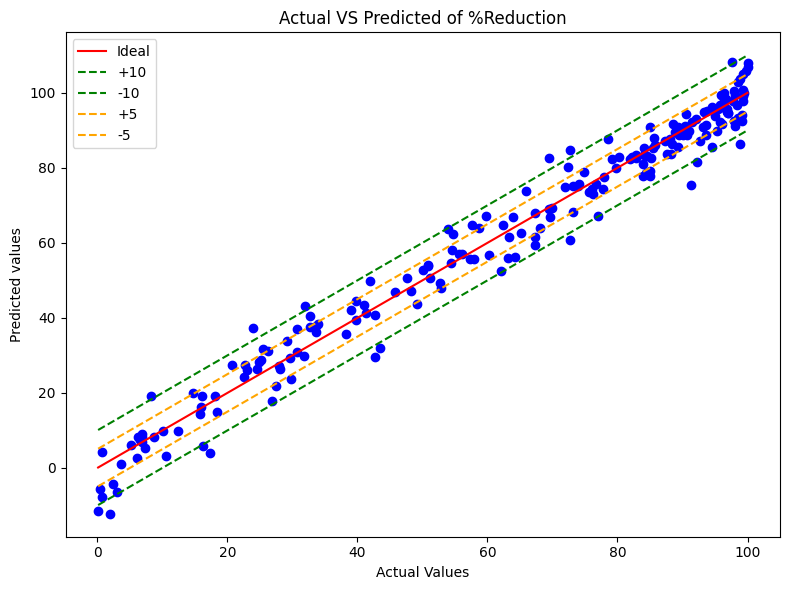

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Ideal')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min() + 10, y_test.max() + 10],
         'g--', label='+10')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min() - 10, y_test.max() - 10],
         'g--', label='-10')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min() + 5, y_test.max() + 5],
         'orange', linestyle='--', label='+5')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min() - 5, y_test.max() - 5],
         'orange', linestyle='--', label='-5')

plt.title('Actual VS Predicted of %Reduction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted values')
plt.legend()
plt.tight_layout()
plt.show()

##Residual Plot

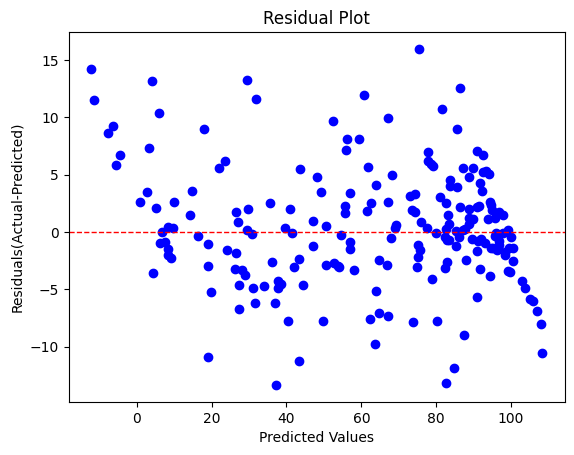

In [ ]:
residuals=y_test-y_pred
plt.scatter(y_pred,residuals,color='blue')
plt.axhline(0,color='red',linestyle='--',linewidth=1)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals(Actual-Predicted)')
plt.title('Residual Plot')
plt.show()

In [ ]:
y_test.shape

(205,)

##Split Sensitiviy and K-Fold Cross Validation

Fold-wise R2 Scores: [95.11 92.29 94.34 91.4  94.03]
R2 from K-Fold Cross-Validation: 93.43 %


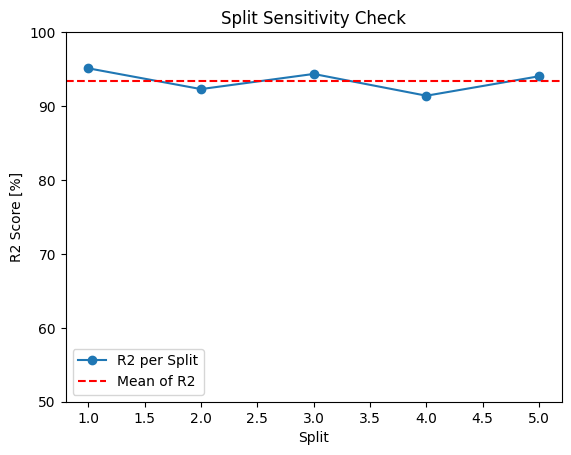

In [ ]:
from sklearn.model_selection import KFold,cross_val_score,cross_val_predict
from sklearn.metrics import root_mean_squared_error
kf=KFold(n_splits=5,shuffle=True,random_state=1)
cv_scores=cross_val_score(xgb_model,X_train,y_train,cv=kf,scoring='r2')
print("Fold-wise R2 Scores:", np.round(cv_scores*100,2))
print("R2 from K-Fold Cross-Validation: {:.2f} %".format(cv_scores.mean()*100))
plt.plot(range(1,6),cv_scores*100,marker='o',label='R2 per Split')
plt.axhline(cv_scores.mean()*100,color='red',linestyle='--',label='Mean of R2')
plt.xlabel('Split')
plt.ylabel('R2 Score [%]')
plt.ylim(50,100)
plt.title('Split Sensitivity Check')
plt.legend()
plt.show()

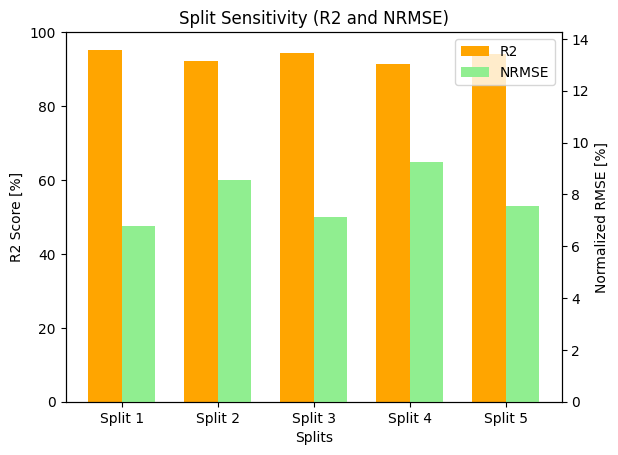

In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse_scores = []
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    xgb_model.fit(X_tr, y_tr)
    y_pred = xgb_model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred) * 100 / (y_val.max() - y_val.min())
    rmse_scores.append(rmse)

x = np.arange(1, 6)
width = 0.35
fig, ax1 = plt.subplots()

bars1 = ax1.bar(x - width/2, cv_scores * 100, width, color='orange', label='R²')
ax1.set_ylabel('R2 Score [%]')
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Split {i}' for i in x])
ax1.set_xlabel('Splits')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, rmse_scores, width, color='lightgreen', label='NRMSE')
ax2.set_ylabel('Normalized RMSE [%]')
ax2.set_ylim(0, max(rmse_scores) + 5)

plt.title('Split Sensitivity (R2 and NRMSE)')
handles = [bars1[0], bars2[0]]
labels = ['R2', 'NRMSE']
ax1.legend(handles, labels, loc='upper right')
plt.show()

##SHAP Analysis

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.29805672908916814, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=929, n_jobs=None,
             num_parallel_tree=None, ...)

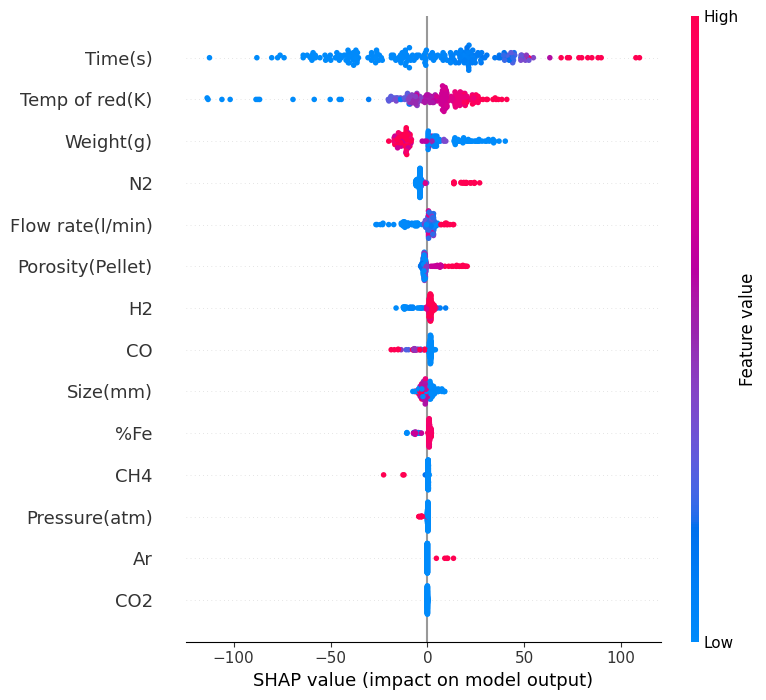

In [ ]:
import shap
import pandas as pd

feature_names = [
    'Temp of red(K)', 'Time(s)', 'Flow rate(l/min)', 'H2', 'CO', 'CO2', 'CH4', 'N2', 'Ar',
    'Weight(g)', '%Fe', 'Size(mm)', 'Porosity(Pellet)', 'Pressure(atm)']

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.Explainer(xgb_model, X_train_df)
shap_values = explainer(X_test_df)
shap.summary_plot(shap_values, X_test_df)

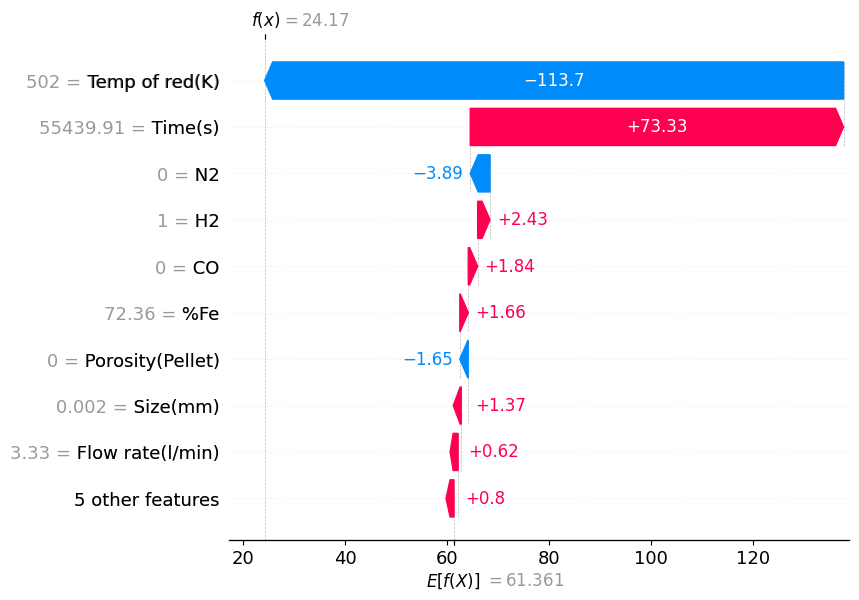

In [ ]:
shap.plots.waterfall(shap_values[0])

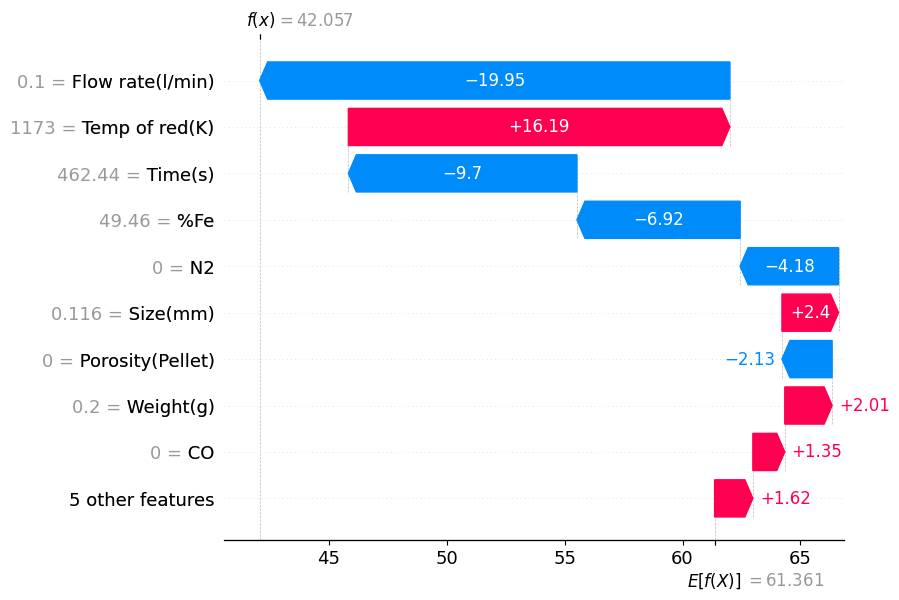

In [ ]:
shap.plots.waterfall(shap_values[1])

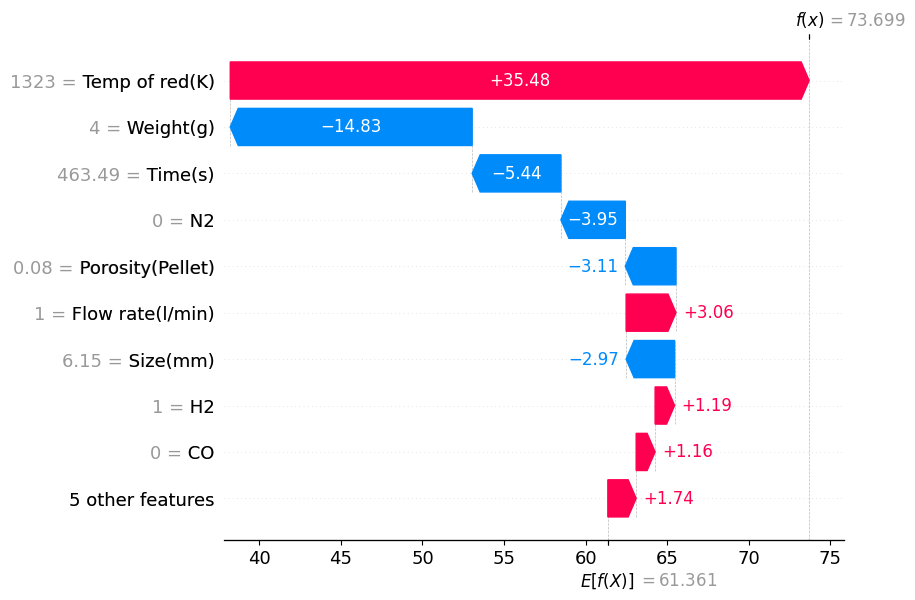

In [ ]:
shap.plots.waterfall(shap_values[3])

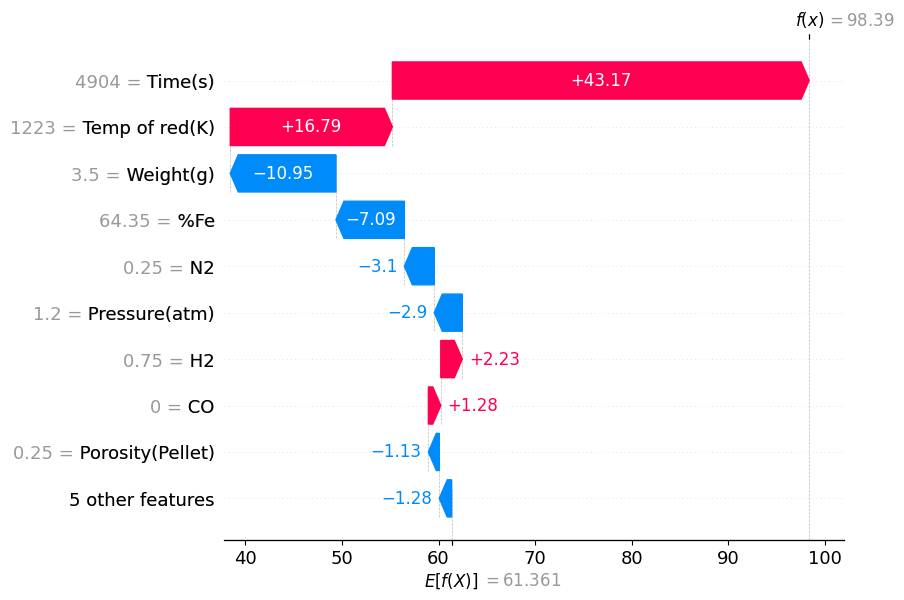

In [ ]:
shap.plots.waterfall(shap_values[4])

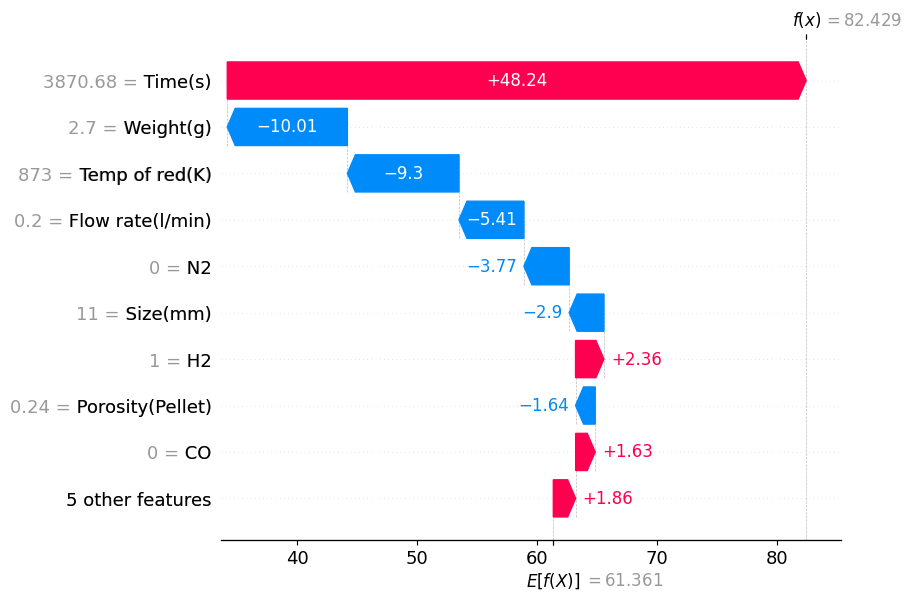

In [ ]:
shap.plots.waterfall(shap_values[5])

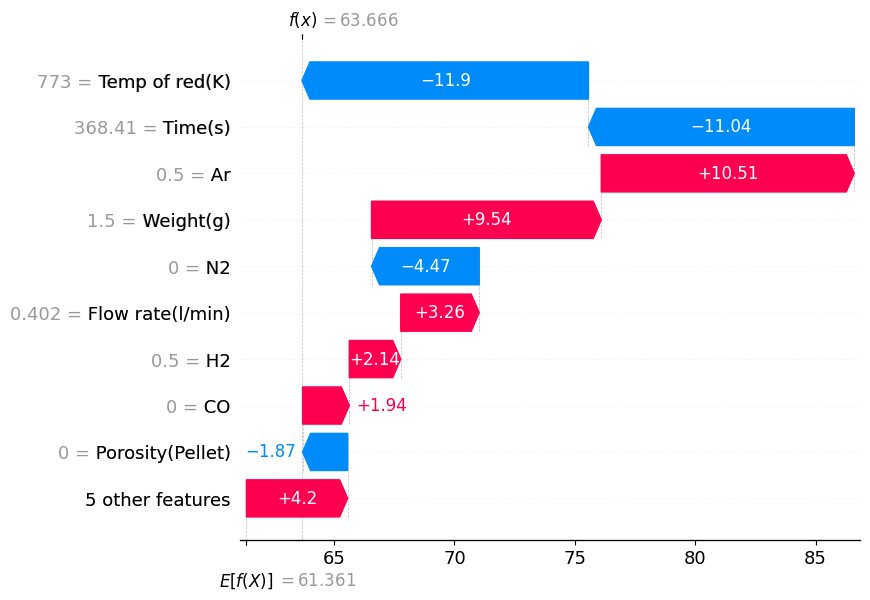

In [ ]:
shap.plots.waterfall(shap_values[11])

In [ ]:
X_test.shape

(205, 14)

In [ ]:
print(y_test)

[ 22.55  38.96  97.69  65.87  96.34  81.95  89.52  45.71  93.82  74.81
  90.71  53.91  28.14  93.14   6.54  54.75  99.77  98.05  76.64  77.9
  90.    92.14  84.39  91.5   84.03  84.93  97.98   3.61  95.97  57.87
  48.19  52.81  79.81  88.57  67.36  59.76  95.91  98.58  26.85  65.11
  84.53  30.71  27.97  99.23  96.81  10.51  41.33  88.46  50.09  98.44
 100.    90.33  76.11  67.35  85.73  94.47   0.76  51.19  33.87  82.85
  54.62  47.69  96.    54.4   67.32   6.83  94.96  99.2   63.3   39.85
  89.38  88.2   55.63  90.47  71.92  96.87  24.88  88.8   10.11   0.13
  85.07  50.79  16.02   8.28  99.31  58.68  57.33  73.1   32.77  82.8
   5.26  18.05  84.98  72.77  52.78  95.47  76.19  88.05  69.62   6.88
  79.18  85.55  99.35  41.96  99.16  91.27   0.79  15.73  38.2   73.1
  18.42   2.36 100.     7.38  17.28  75.58  31.8   92.69  73.97  82.17
  16.24  78.57  25.12  12.49  56.15  39.79  22.78  32.69  64.29  96.33
  20.67  97.87   6.84  94.58  96.67  93.6   29.24  87.69  68.09  49.15
  31.95  

##ICE + PDP plots

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

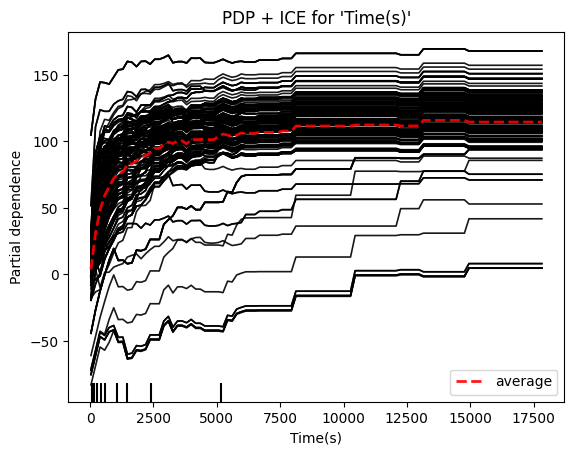

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_model,X_test_df,features=['Time(s)'],kind='both',
                                        line_kw={"color":"black","linewidth": 1.2,"alpha":0.9},
                                        pd_line_kw={"color":"red","linestyle": "--","linewidth":2})
plt.title("PDP + ICE for 'Time(s)'")
plt.show()

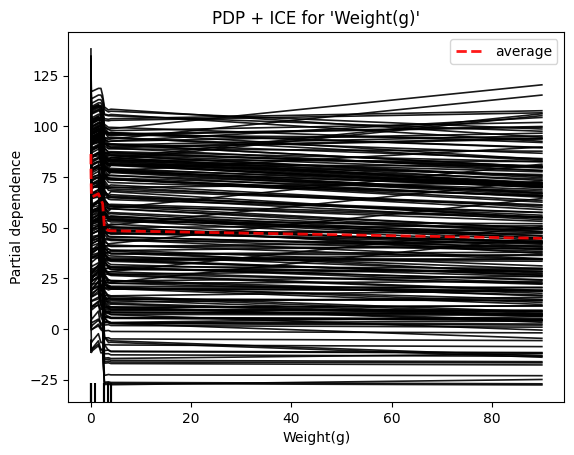

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_model,X_test_df,features=['Weight(g)'],kind='both',
                                        line_kw={"color":"black","linewidth": 1.2,"alpha":0.9},
                                        pd_line_kw={"color":"red","linestyle": "--","linewidth":2})
plt.title("PDP + ICE for 'Weight(g)'")
plt.show()

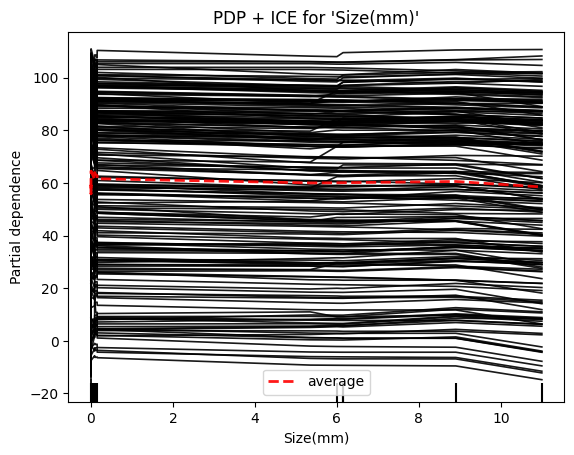

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_model,X_test_df,features=['Size(mm)'],kind='both',
                                        line_kw={"color":"black","linewidth": 1.2,"alpha":0.9},
                                        pd_line_kw={"color":"red","linestyle": "--","linewidth":2})
plt.title("PDP + ICE for 'Size(mm)'")
plt.show()

In [ ]:
X_test.shape

(205, 14)

##Model Compaision

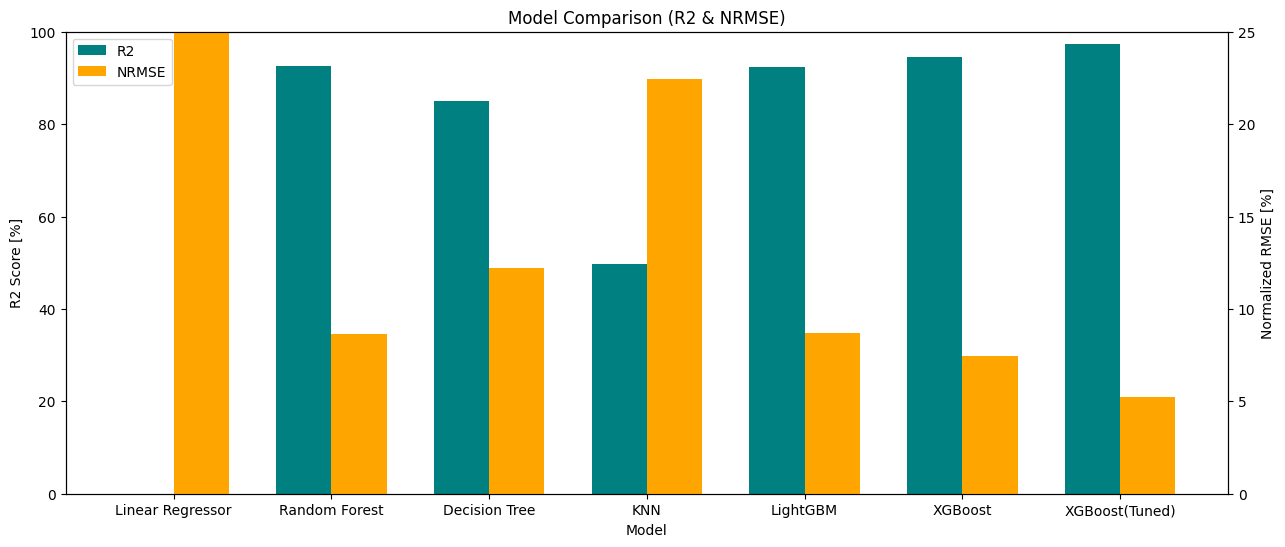

In [ ]:
models=['Linear Regressor','Random Forest', 'Decision Tree','KNN','LightGBM','XGBoost','XGBoost(Tuned)']

r2_scores=[-0.03,92.52,84.99,49.63,92.45,94.46,97.24]
nrmse_percent=[32.05,8.64,12.23,22.42,8.68,7.43,5.25]
x=np.arange(len(models))
width=0.35
fig,ax1=plt.subplots(figsize=(15,6))

bars1=ax1.bar(x-width/2,r2_scores,width,color='teal',label='R2')
ax1.set_ylabel('R2 Score [%]')
ax1.set_ylim(0,100)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_xlabel('Model')

ax2=ax1.twinx()
bars2=ax2.bar(x+width/2,nrmse_percent,width, color='orange',label='NRMSE')
ax2.set_ylabel('Normalized RMSE [%]')
ax2.set_ylim(0,25)

plt.title('Model Comparison (R2 & NRMSE)')
handles=[bars1[0],bars2[0]]
labels=['R2','NRMSE']
ax1.legend(handles,labels,loc='upper left')
plt.show()

##Feature Reduction

###Significance Level - 25%

In [ ]:
from sklearn.feature_selection import f_regression

feature_names = [
    'Temp Gas(K)', 'Time(s)', 'Flow rate(l/min)', 'H2', 'CO', 'CO2', 'CH4', 'N2', 'Ar',
     'Weight(g)', '%Fe', 'Size(mm)', 'Porosity(Pellet)', 'Pressure(atm)']

X_df = pd.DataFrame(X, columns=feature_names)

f_vals, p_vals = f_regression(X_df, y)
feature_significance = pd.DataFrame({
    'Insinificant Feature': X_df.columns,
    'P-Value': p_vals
})

insignificant_features = feature_significance[feature_significance['P-Value'] > 0.25]
print(insignificant_features)

X_drop = X_df.drop(columns=insignificant_features['Insinificant Feature'])

  Insinificant Feature   P-Value
2     Flow rate(l/min)  0.546134
5                  CO2  0.385217
6                  CH4  0.655850
7                   N2  0.480069
8                   Ar  0.588746


In [ ]:
X_drop.shape

(1023, 9)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_drop, y, test_size=0.2, random_state=1)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("NRMSE:", root_mean_squared_error(y_test, y_pred) * 100 / (y_test.max() - y_test.min()), "%")

R2 Score: 0.9019398993231775
NRMSE: 9.894023550332648 %


###Significance Level - 10%

In [ ]:
insignificant_features = feature_significance[feature_significance['P-Value'] > 0.10]
print(insignificant_features)

X_drop = X_df.drop(columns=insignificant_features['Insinificant Feature'])

   Insinificant Feature   P-Value
0           Temp Gas(K)  0.145178
2      Flow rate(l/min)  0.546134
3                    H2  0.167991
5                   CO2  0.385217
6                   CH4  0.655850
7                    N2  0.480069
8                    Ar  0.588746
12     Porosity(Pellet)  0.133136


In [ ]:
X_drop.shape

(1023, 6)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_drop, y, test_size=0.2, random_state=1)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("NRMSE:", root_mean_squared_error(y_test, y_pred) * 100 / (y_test.max() - y_test.min()), "%")

R2 Score: 0.6073017553440718
NRMSE: 19.799592514861715 %


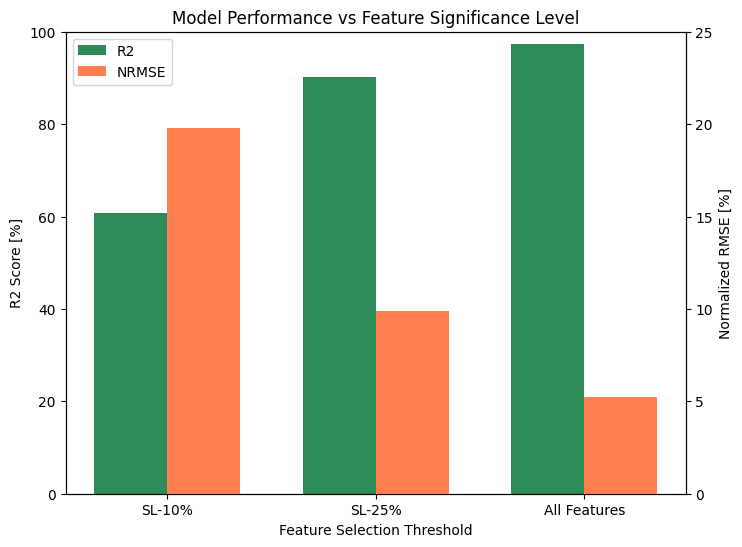

In [ ]:
feature_sets = ['SL-10%', 'SL-25%', 'All Features']
r2_scores = [60.73, 90.19, 97.24]
nrmse_percent = [19.79, 9.89, 5.25]

x = np.arange(len(feature_sets))
width = 0.35
fig, ax1 = plt.subplots(figsize=(8, 6))

bars1 = ax1.bar(x - width/2, r2_scores, width, color='seagreen', label='R2')
ax1.set_ylabel('R2 Score [%]')
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(feature_sets)
ax1.set_xlabel('Feature Selection Threshold')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, nrmse_percent, width, color='coral', label='NRMSE')
ax2.set_ylabel('Normalized RMSE [%]')
ax2.set_ylim(0, 25)

plt.title('Model Performance vs Feature Significance Level')
handles = [bars1[0], bars2[0]]
labels = ['R2', 'NRMSE']
ax1.legend(handles, labels, loc='upper left')
plt.show()